# 연고관광 클러스터별 지역 잠재력·지원지역 점수

## 분석 목적과 범위

`docs/note/260726_연고관광_클러스터_해석_및_지역점수_설계.md`의
산식을 실제 229개 시군구 자료에 적용한다.

- 2023~2025년 국민여행조사의 지역별 연고방문 수요와 CASE 2 군집
  구성비를 사용한다.
- 관광·상권·교통 공급을 전국 시군구 내 0~100 백분위 점수로 변환한다.
- 다섯 클러스터별 잠재력 점수와 구성비 보정 최종 점수를 계산한다.
- 인구감소지역은 점수 가산점이 아니라 최종 정책대상 필터로만 사용한다.
- 핵심 가중치, 정책 시나리오, CASE 2 N 보정 기준에 대한 민감도를
  비교한다.

분석 단위는 **시군구 1행**이다. 국민여행조사 피처는 여행·방문지
집계 결과이며, 연고방문은 CASE 2·3을 뜻한다. 출생지나 법적 고향을
직접 측정하지 않고, 점수는 정책 효과의 인과 추정치가 아닌 탐색적
우선순위 지표다.

## 구현 기준과 주요 가정

- 시설 수·밀도는 각각 백분위 점수로 바꾼 뒤 50:50으로 결합한다.
- 군위군은 현재 관광·교통·인구감소지역 자료의 기준에 맞춰
  `경상북도-군위군 → 대구광역시-군위군` 교차표를 **분석용 키에만**
  적용한다. 국민여행조사 원본 열과 원본 파일은 변경하지 않는다.
- 전국 군집 사전비율은 다섯 `군집..._가중규모`의 전국 합으로 계산한다.
- 기본 구성비 보정 기준은 CASE 2 N=50이며, 30·70을 민감도에서 비교한다.
- 시나리오는 수요 중심(D), 전환 필요 중심(G), 공급 중심(현재 사용 중인
  공급 하위지수 묶음)의 비중을 각각 10%p 높이고 나머지 비중을
  비례 축소하는 방식으로 구현한다.
- 지원검토 상위지역은 대표여행 신뢰 플래그가 참인 지역 내 상위 20개로
  정의한다. 상위 20개 중 CASE 2 N<30은 `관찰지역`으로 표시한다.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import spearmanr


def find_project_root(start: Path) -> Path:
    """현재 위치에서 프로젝트 루트를 찾는다.

    Args:
        start: 탐색을 시작할 경로.

    Returns:
        `src`와 `data` 디렉터리를 가진 프로젝트 루트.

    Raises:
        FileNotFoundError: 프로젝트 루트를 찾지 못했을 때.
    """
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.path import (  # noqa: E402
    FEATURES_BY_REGION_DIR,
    POP_DECLINE_DANGER_REGION_PATH,
    create_output_directories,
)
from src.visualization import (  # noqa: E402
    COLORS,
    PALETTE,
    apply_plot_style,
)

NOTEBOOK_FILENAME = "260726_연고관광_클러스터별_지역점수.ipynb"
RANDOM_SEED = 20260726
BASE_SHRINKAGE_N = 50
SHRINKAGE_THRESHOLDS = (30, 50, 70)
TOP_N = 20

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.3f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)

FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_FILENAME)

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"그림 저장 경로: {FIGURES_DIR}")
print(f"표 저장 경로: {TABLES_DIR}")

프로젝트 루트: C:\Users\ilove\OneDrive\Desktop\tourism_poster
그림 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_1035\figures
표 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_1035\tables


In [2]:
TRAVEL_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR
    / "sigungu_all_trip_features_2023_2025.csv"
)
TRAVEL_CODEBOOK_PATH = (
    FEATURES_BY_REGION_DIR
    / "sigungu_all_trip_features_2023_2025_codebook.csv"
)
TOURISM_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR / "sigungu_tourism_wide_table.csv"
)
TRANSPORT_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR / "sigungu_transportation_wide_table.csv"
)
POPULATION_DECLINE_PATH = POP_DECLINE_DANGER_REGION_PATH

REGION_KEYS = ["시도명", "시군구명"]
CLUSTER_LABELS = [
    "당일 C1",
    "당일 C2",
    "숙박 C1",
    "숙박 C2",
    "숙박 C3",
]
RAW_SHARE_COLUMNS = {
    "당일 C1": "군집당일여행 C1_구성비",
    "당일 C2": "군집당일여행 C2_구성비",
    "숙박 C1": "군집숙박여행 C1_구성비",
    "숙박 C2": "군집숙박여행 C2_구성비",
    "숙박 C3": "군집숙박여행 C3_구성비",
}
CLUSTER_SIZE_COLUMNS = {
    "당일 C1": "군집당일여행 C1_가중규모",
    "당일 C2": "군집당일여행 C2_가중규모",
    "숙박 C1": "군집숙박여행 C1_가중규모",
    "숙박 C2": "군집숙박여행 C2_가중규모",
    "숙박 C3": "군집숙박여행 C3_가중규모",
}
POPULATION_SIDO_MAP = {
    "부산": "부산광역시",
    "대구": "대구광역시",
    "인천": "인천광역시",
    "경기": "경기도",
    "강원": "강원도",
    "충북": "충청북도",
    "충남": "충청남도",
    "전북": "전라북도",
    "전남": "전라남도",
    "경북": "경상북도",
    "경남": "경상남도",
}

input_paths = pd.Series(
    {
        "국민여행조사 지역 피처": TRAVEL_FEATURE_PATH,
        "국민여행조사 피처 코드북": TRAVEL_CODEBOOK_PATH,
        "관광·상권 피처": TOURISM_FEATURE_PATH,
        "교통 피처": TRANSPORT_FEATURE_PATH,
        "인구감소지역 목록": POPULATION_DECLINE_PATH,
    },
    name="입력 경로",
)
display(input_paths.to_frame())

,입력 경로
국민여행조사 지역 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
국민여행조사 피처 코드북,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
관광·상권 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
교통 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
인구감소지역 목록,C:\Users\ilove\OneDrive\Desktop\tourism_poster...


## 데이터 로드

국민여행조사 표의 군집 구성비는 군집 라벨이 있는 대표 CASE 2
여행-시군구 집계다. `case2_trip_n_all_trip_case15`는 전체 CASE 2
여행-시군구 건수이므로 구성비 안정화의 정확한 분모가 아닌 현재 사용
가능한 대리변수다.

In [3]:
travel_raw = pd.read_csv(TRAVEL_FEATURE_PATH)
travel_codebook = pd.read_csv(TRAVEL_CODEBOOK_PATH)
tourism_raw = pd.read_csv(TOURISM_FEATURE_PATH)
transport_raw = pd.read_csv(TRANSPORT_FEATURE_PATH)
population_raw = pd.read_csv(
    POPULATION_DECLINE_PATH,
    encoding="utf-8-sig",
)

loaded_shapes = pd.DataFrame(
    {
        "행": [
            len(travel_raw),
            len(travel_codebook),
            len(tourism_raw),
            len(transport_raw),
            len(population_raw),
        ],
        "열": [
            travel_raw.shape[1],
            travel_codebook.shape[1],
            tourism_raw.shape[1],
            transport_raw.shape[1],
            population_raw.shape[1],
        ],
    },
    index=[
        "국민여행조사 지역 피처",
        "지역 피처 코드북",
        "관광·상권 피처",
        "교통 피처",
        "인구감소지역",
    ],
)
print("입력 파일의 분석 단위와 크기를 확인한다.")
display(loaded_shapes)

입력 파일의 분석 단위와 크기를 확인한다.


,행,열
국민여행조사 지역 피처,229,57
지역 피처 코드북,57,12
관광·상권 피처,229,187
교통 피처,229,8
인구감소지역,89,2


## 데이터 품질과 분석 단위 확인

결합 전 원래 명칭 기준의 미매칭과, 명시적 군위군 교차표 적용 후
결합 상태를 모두 기록한다. 결합은 `시도명 + 시군구명` 복합키,
`one_to_one` 검증을 사용한다.

In [4]:
def duplicate_key_count(frame: pd.DataFrame) -> int:
    """시도·시군구 복합키의 중복 행 수를 계산한다.

    Args:
        frame: 지역 키를 가진 데이터프레임.

    Returns:
        중복으로 표시된 행 수.
    """
    return int(frame.duplicated(REGION_KEYS, keep=False).sum())


def anti_join_keys(
    left: pd.DataFrame,
    right: pd.DataFrame,
) -> pd.DataFrame:
    """왼쪽에만 존재하는 지역 복합키를 반환한다.

    Args:
        left: 기준 데이터프레임.
        right: 비교 데이터프레임.

    Returns:
        왼쪽에만 존재하는 고유 지역 키.
    """
    return (
        left[REGION_KEYS]
        .drop_duplicates()
        .merge(
            right[REGION_KEYS].drop_duplicates(),
            on=REGION_KEYS,
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        .loc[lambda frame: frame["_merge"].eq("left_only"), REGION_KEYS]
        .reset_index(drop=True)
    )


raw_travel_only = anti_join_keys(travel_raw, tourism_raw)
raw_tourism_only = anti_join_keys(tourism_raw, travel_raw)

print("군위군 교차표 적용 전 양쪽 미매칭 키를 확인한다.")
display(
    pd.concat(
        {
            "국민여행조사에만 있음": raw_travel_only,
            "관광표에만 있음": raw_tourism_only,
        },
        names=["구분", "행"],
    )
)

군위군 교차표 적용 전 양쪽 미매칭 키를 확인한다.


,,시도명,시군구명
구분,행,,
국민여행조사에만 있음,0,경상북도,군위군
관광표에만 있음,0,대구광역시,군위군


In [5]:
travel = travel_raw.copy()
travel["조사_시도명"] = travel["시도명"]
gunwi_mask = (
    travel["시도명"].eq("경상북도")
    & travel["시군구명"].eq("군위군")
)
travel.loc[gunwi_mask, "시도명"] = "대구광역시"
travel["군위군_분석키_교차표적용"] = gunwi_mask

population = population_raw.rename(
    columns={"sigungu": "시군구명"}
).copy()
population["시도명"] = population["sido"].map(POPULATION_SIDO_MAP)
if population["시도명"].isna().any():
    unknown_sido = population.loc[
        population["시도명"].isna(),
        "sido",
    ].unique()
    raise ValueError(f"미정의 인구감소지역 시도 약칭: {unknown_sido}")

for name, frame in {
    "국민여행조사": travel,
    "관광·상권": tourism_raw,
    "교통": transport_raw,
    "인구감소지역": population,
}.items():
    if duplicate_key_count(frame) != 0:
        raise ValueError(f"{name} 지역 복합키가 유일하지 않습니다.")

population_unmatched = anti_join_keys(population, tourism_raw)
if not population_unmatched.empty:
    raise ValueError(
        "현재 기준으로도 미매칭 인구감소지역이 있습니다:\n"
        f"{population_unmatched}"
    )

regional = travel.merge(
    tourism_raw,
    on=REGION_KEYS,
    how="left",
    validate="one_to_one",
)
regional = regional.merge(
    transport_raw,
    on=REGION_KEYS,
    how="left",
    validate="one_to_one",
)
regional = regional.merge(
    population[REGION_KEYS].assign(인구감소지역=True),
    on=REGION_KEYS,
    how="left",
    validate="one_to_one",
)
regional["인구감소지역"] = (
    regional["인구감소지역"].fillna(False).astype(bool)
)
regional["지역명"] = (
    regional["시도명"] + " " + regional["시군구명"]
)

print("명시적 교차표 적용 후 결합 상태를 확인한다.")
display(
    pd.Series(
        {
            "결합 행 수": len(regional),
            "결합 키 중복 행": duplicate_key_count(regional),
            "전체 결측 셀": int(regional.isna().sum().sum()),
            "군위군 교차표 적용 행": int(gunwi_mask.sum()),
            "인구감소지역 일치 수": int(
                regional["인구감소지역"].sum()
            ),
        },
        name="값",
    ).to_frame()
)

명시적 교차표 적용 후 결합 상태를 확인한다.


C:\Users\ilove\AppData\Local\Temp\ipykernel_22904\3719144219.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  regional["지역명"] = (


,값
결합 행 수,229
결합 키 중복 행,0
전체 결측 셀,0
군위군 교차표 적용 행,1
인구감소지역 일치 수,89


In [6]:
raw_share_columns = list(RAW_SHARE_COLUMNS.values())
raw_share_sum = regional[raw_share_columns].sum(axis=1)
case23_denom = (
    regional["CASE2_연고방문_관광포함"]
    + regional["CASE3_연고방문_관광미포함"]
)

if not np.allclose(raw_share_sum, 1.0, atol=1e-10):
    raise ValueError("다섯 원 군집 구성비의 합이 1이 아닙니다.")
if case23_denom.le(0).any():
    raise ValueError("CASE 2·3 가중 합이 0 이하인 지역이 있습니다.")
if regional["면적_km2"].le(0).any():
    raise ValueError("면적이 0 이하인 지역이 있습니다.")

sample_quality = pd.Series(
    {
        "CASE 2 N<30 지역": int(
            regional["case2_trip_n_all_trip_case15"].lt(30).sum()
        ),
        "CASE 2 N<50 지역": int(
            regional["case2_trip_n_all_trip_case15"].lt(50).sum()
        ),
        "CASE 2 N<70 지역": int(
            regional["case2_trip_n_all_trip_case15"].lt(70).sum()
        ),
        "대표여행 신뢰 플래그=False 지역": int(
            (~regional["is_reliable_rep_trip_case124"]).sum()
        ),
        "원 군집 구성비 합 최소": raw_share_sum.min(),
        "원 군집 구성비 합 최대": raw_share_sum.max(),
    },
    name="값",
)
print("지역별 군집 구성비와 표본 신뢰도를 확인한다.")
display(sample_quality.to_frame())

지역별 군집 구성비와 표본 신뢰도를 확인한다.


,값
CASE 2 N<30 지역,66.000
CASE 2 N<50 지역,108.000
CASE 2 N<70 지역,148.000
대표여행 신뢰 플래그=False 지역,2.000
원 군집 구성비 합 최소,1.000
원 군집 구성비 합 최대,1.000


## 0~100 백분위 점수와 하위지수 계산

동률에는 평균 순위를 사용한다.

\[
R(x_r)=100\frac{\operatorname{rank}(x_r)-1}{n-1}
\]

시설 수와 밀도는 다음처럼 결합한다.

\[
C(x)=0.5R(\text{시설 수})+0.5R(\text{시설 밀도})
\]

In [7]:
def percentile_score(values: pd.Series) -> pd.Series:
    """수치를 평균 동률 순위 기반 0~100점으로 변환한다.

    Args:
        values: 결측이 없는 수치형 지역 지표.

    Returns:
        원래 인덱스를 유지한 백분위 점수.

    Raises:
        ValueError: 결측 또는 무한값이 있거나 유효 지역이 2개 미만일 때.
    """
    numeric = pd.to_numeric(values, errors="coerce")
    if numeric.isna().any() or not np.isfinite(numeric).all():
        raise ValueError(f"{values.name}에 결측 또는 무한값이 있습니다.")
    if len(numeric) < 2:
        raise ValueError("백분위 계산에는 지역이 2개 이상 필요합니다.")
    ranks = numeric.rank(method="average")
    return 100.0 * (ranks - 1.0) / (len(numeric) - 1.0)


def combined_resource_score(
    frame: pd.DataFrame,
    count_column: str,
    density_column: str | None = None,
) -> pd.Series:
    """시설 수와 면적당 밀도의 백분위 점수를 50:50으로 결합한다.

    Args:
        frame: 시설 수와 면적 열을 가진 지역 데이터.
        count_column: 시설 수 열 이름.
        density_column: 이미 계산된 밀도 열 이름. 없으면 면적으로 계산한다.

    Returns:
        수·밀도 결합점수.
    """
    count = frame[count_column]
    if density_column is None:
        density = count / frame["면적_km2"]
        density.name = f"{count_column}_면적당"
    else:
        density = frame[density_column]
    return (
        0.5 * percentile_score(count)
        + 0.5 * percentile_score(density)
    )

In [8]:
experience_resource_pairs = {
    "체험교육": ("관광지수_체험/교육", "관광지밀도_체험/교육"),
    "축제테마": ("관광지수_축제/테마", "관광지밀도_축제/테마"),
    "레저스포츠": (
        "관광지수_레저/스포츠",
        "관광지밀도_레저/스포츠",
    ),
    "휴양온천": ("관광지수_휴양/온천", "관광지밀도_휴양/온천"),
    "유원지오락": (
        "상권중분류수_유원지·오락(R104)",
        "상권중분류밀도_유원지·오락(R104)",
    ),
    "스포츠서비스": (
        "상권중분류수_스포츠 서비스(R103)",
        "상권중분류밀도_스포츠 서비스(R103)",
    ),
    "예술스포츠여가": (
        "관광대분류수_예술스포츠여가",
        "관광대분류밀도_예술스포츠여가",
    ),
}
resource_scores = pd.DataFrame(
    {
        label: combined_resource_score(regional, count, density)
        for label, (count, density) in experience_resource_pairs.items()
    }
)

family_resource_labels = ["체험교육", "축제테마", "유원지오락"]
food_score = combined_resource_score(
    regional,
    "관광대분류수_음식점업",
    "관광대분류밀도_음식점업",
)
lodging_score = combined_resource_score(
    regional,
    "관광대분류수_숙박업_기타제외",
    "관광대분류밀도_숙박업_기타제외",
)
transit_score = (
    0.35
    * combined_resource_score(regional, "철도역수")
    + 0.35
    * combined_resource_score(regional, "고속버스터미널수")
    + 0.30
    * combined_resource_score(regional, "버스정류장수")
)
road_score = combined_resource_score(
    regional,
    "고속도로출입시설수_IC",
)
solo_consumption_score = (
    0.30 * food_score
    + 0.25
    * combined_resource_score(
        regional,
        "상권중분류수_비알코올 (I212)",
        "상권중분류밀도_비알코올 (I212)",
    )
    + 0.20
    * combined_resource_score(
        regional,
        "상권중분류수_종합 소매(G204)",
        "상권중분류밀도_종합 소매(G204)",
    )
    + 0.15
    * combined_resource_score(
        regional,
        "상권중분류수_섬유·의복·신발 소매(G209)",
        "상권중분류밀도_섬유·의복·신발 소매(G209)",
    )
    + 0.10
    * combined_resource_score(
        regional,
        "상권중분류수_주점(I211)",
        "상권중분류밀도_주점(I211)",
    )
)

conversion_ratio = (
    regional["CASE3_연고방문_관광미포함"] / case23_denom
)
subindices = pd.DataFrame(
    {
        "D": (
            0.5
            * percentile_score(
                regional[
                    "hometown_visit_weighted_all_trip_case23"
                ]
            )
            + 0.5
            * percentile_score(
                regional[
                    "hometown_visit_share_w_all_trip_case15_pct"
                ]
            )
        ),
        "G": percentile_score(conversion_ratio),
        "E": resource_scores.mean(axis=1),
        "E_family": resource_scores[family_resource_labels].mean(
            axis=1
        ),
        "B": combined_resource_score(
            regional,
            "관광지수_총합",
            "관광지밀도_총합",
        ),
        "F_food": food_score,
        "L": lodging_score,
        "T": transit_score,
        "A": road_score,
        "C_solo": solo_consumption_score,
        "P": percentile_score(
            100.0
            - regional[
                "no_reservation_rate_w_rep_trip_case124_pct"
            ]
        ),
        "H": percentile_score(
            regional[
                "activity_potential_rep_trip_case124_pct"
            ]
        ),
        "Q": (
            0.5
            * percentile_score(
                regional[
                    "revisit_intent_mean_w_rep_trip_case124"
                ]
            )
            + 0.5
            * percentile_score(
                regional[
                    "satisfaction_mean_w_rep_trip_case124"
                ]
            )
        ),
    },
    index=regional.index,
)
subindices["flex"] = subindices[["A", "T"]].max(axis=1)

subindex_summary = subindices.agg(["min", "mean", "max"]).T
print("공통 하위지수의 전국 시군구 범위를 확인한다.")
display(subindex_summary.round(2))

공통 하위지수의 전국 시군구 범위를 확인한다.


,min,mean,max
D,0.000,50.000,93.860
G,0.000,50.000,100.000
E,23.750,50.000,80.370
E_family,29.240,50.000,90.200
B,14.250,50.000,99.560
F_food,0.000,50.000,97.590
L,0.440,50.000,98.030
T,20.110,50.000,85.780
A,15.130,50.000,98.680
C_solo,0.700,50.000,96.590


## 클러스터별 잠재력 점수

설계안의 가중치를 그대로 사용한다. 군집 구성비는 이 단계에 넣지 않고
마지막 지역 점수 결합에서 한 번만 사용한다.

In [9]:
weight_table = pd.DataFrame(
    {
        "당일 C1": {
            "D": 0.20,
            "G": 0.15,
            "E": 0.30,
            "E_family": 0.10,
            "B": 0.00,
            "F_food": 0.00,
            "L": 0.00,
            "T": 0.00,
            "A": 0.00,
            "flex": 0.00,
            "C_solo": 0.00,
            "P": 0.15,
            "H": 0.05,
            "Q": 0.05,
        },
        "당일 C2": {
            "D": 0.30,
            "G": 0.25,
            "E": 0.00,
            "E_family": 0.00,
            "B": 0.20,
            "F_food": 0.10,
            "L": 0.00,
            "T": 0.00,
            "A": 0.00,
            "flex": 0.10,
            "C_solo": 0.00,
            "P": 0.00,
            "H": 0.00,
            "Q": 0.05,
        },
        "숙박 C1": {
            "D": 0.15,
            "G": 0.10,
            "E": 0.30,
            "E_family": 0.00,
            "B": 0.00,
            "F_food": 0.10,
            "L": 0.20,
            "T": 0.00,
            "A": 0.00,
            "flex": 0.05,
            "C_solo": 0.00,
            "P": 0.05,
            "H": 0.00,
            "Q": 0.05,
        },
        "숙박 C2": {
            "D": 0.20,
            "G": 0.10,
            "E": 0.00,
            "E_family": 0.00,
            "B": 0.05,
            "F_food": 0.00,
            "L": 0.10,
            "T": 0.30,
            "A": 0.00,
            "flex": 0.00,
            "C_solo": 0.20,
            "P": 0.00,
            "H": 0.00,
            "Q": 0.05,
        },
        "숙박 C3": {
            "D": 0.30,
            "G": 0.05,
            "E": 0.00,
            "E_family": 0.00,
            "B": 0.20,
            "F_food": 0.15,
            "L": 0.15,
            "T": 0.00,
            "A": 0.10,
            "flex": 0.00,
            "C_solo": 0.00,
            "P": 0.00,
            "H": 0.00,
            "Q": 0.05,
        },
    }
)
weight_sums = weight_table.sum(axis=0)
if not np.allclose(weight_sums, 1.0, atol=1e-12):
    raise ValueError("클러스터별 가중치 합이 1이 아닙니다.")

print("클러스터별 하위지수 가중치와 합을 확인한다.")
display(
    pd.concat(
        [weight_table, weight_sums.to_frame().T.rename(index={0: "합계"})]
    ).style.format("{:.2f}")
)

클러스터별 하위지수 가중치와 합을 확인한다.


,당일 C1,당일 C2,숙박 C1,숙박 C2,숙박 C3
D,0.20,0.30,0.15,0.20,0.30
G,0.15,0.25,0.10,0.10,0.05
E,0.30,0.00,0.30,0.00,0.00
E_family,0.10,0.00,0.00,0.00,0.00
B,0.00,0.20,0.00,0.05,0.20
F_food,0.00,0.10,0.10,0.00,0.15
L,0.00,0.00,0.20,0.10,0.15
T,0.00,0.00,0.00,0.30,0.00
A,0.00,0.00,0.00,0.00,0.10
flex,0.00,0.10,0.05,0.00,0.00


In [10]:
def calculate_cluster_scores(
    indices: pd.DataFrame,
    weights: pd.DataFrame,
) -> pd.DataFrame:
    """하위지수와 가중치로 다섯 클러스터 점수를 계산한다.

    Args:
        indices: 지역별 하위지수 표.
        weights: 하위지수×클러스터 가중치 표.

    Returns:
        지역별 다섯 클러스터 점수.
    """
    missing = weights.index.difference(indices.columns)
    if not missing.empty:
        raise KeyError(f"하위지수가 없습니다: {missing.tolist()}")
    return indices[weights.index].dot(weights)


cluster_scores = calculate_cluster_scores(subindices, weight_table)
cluster_scores.columns = [
    f"클러스터점수_{label}" for label in cluster_scores.columns
]

print("기본 가중치의 클러스터별 점수 범위를 확인한다.")
display(cluster_scores.agg(["min", "mean", "max"]).T.round(2))

기본 가중치의 클러스터별 점수 범위를 확인한다.


,min,mean,max
클러스터점수_당일 C1,26.900,50.000,71.750
클러스터점수_당일 C2,11.460,51.130,81.900
클러스터점수_숙박 C1,22.030,50.560,75.180
클러스터점수_숙박 C2,21.140,50.000,77.470
클러스터점수_숙박 C3,21.950,50.000,79.800


## 지역 군집 구성비 안정화와 최종 점수

\[
q_r=\min(1,n_{r,\mathrm{CASE2}}/50),\qquad
\tilde p_{r,k}=q_rp_{r,k}+(1-q_r)\pi_k
\]

\[
F_r=\sum_k \tilde p_{r,k}S_{r,k}
\]

In [11]:
national_cluster_sizes = pd.Series(
    {
        label: regional[column].sum()
        for label, column in CLUSTER_SIZE_COLUMNS.items()
    }
)
national_cluster_priors = (
    national_cluster_sizes / national_cluster_sizes.sum()
)

def shrink_cluster_shares(
    frame: pd.DataFrame,
    threshold: int,
) -> pd.DataFrame:
    """지역 군집 구성비를 전국 구성비 쪽으로 수축한다.

    Args:
        frame: 원 군집 구성비와 CASE 2 N을 가진 지역 표.
        threshold: 지역 구성비를 온전히 신뢰하는 CASE 2 N 기준.

    Returns:
        클러스터명이 열인 보정 구성비 표.
    """
    reliability = (
        frame["case2_trip_n_all_trip_case15"] / threshold
    ).clip(upper=1.0)
    raw_shares = pd.DataFrame(
        {
            label: frame[column]
            for label, column in RAW_SHARE_COLUMNS.items()
        },
        index=frame.index,
    )
    shrunk = raw_shares.mul(reliability, axis=0).add(
        pd.DataFrame(
            np.outer(1.0 - reliability, national_cluster_priors),
            index=frame.index,
            columns=CLUSTER_LABELS,
        )
    )
    if not np.allclose(shrunk.sum(axis=1), 1.0, atol=1e-10):
        raise ValueError("보정 군집 구성비의 합이 1이 아닙니다.")
    return shrunk


raw_shares = pd.DataFrame(
    {
        label: regional[column]
        for label, column in RAW_SHARE_COLUMNS.items()
    }
)
shrunk_shares = shrink_cluster_shares(
    regional,
    BASE_SHRINKAGE_N,
)
shrunk_shares.columns = [
    f"보정구성비_{label}" for label in shrunk_shares.columns
]

cluster_scores_plain = cluster_scores.rename(
    columns={
        f"클러스터점수_{label}": label
        for label in CLUSTER_LABELS
    }
)
shrunk_shares_plain = shrunk_shares.rename(
    columns={
        f"보정구성비_{label}": label
        for label in CLUSTER_LABELS
    }
)
contributions = shrunk_shares_plain * cluster_scores_plain
final_score = contributions.sum(axis=1)

print("전국 다섯 군집 사전비율과 최종 점수 범위를 확인한다.")
display(
    pd.DataFrame(
        {
            "가중 규모": national_cluster_sizes,
            "전국 구성비": national_cluster_priors,
        }
    ).style.format({"가중 규모": "{:,.0f}", "전국 구성비": "{:.1%}"})
)
display(
    pd.Series(
        {
            "보정 구성비 합 최소": shrunk_shares_plain.sum(axis=1).min(),
            "보정 구성비 합 최대": shrunk_shares_plain.sum(axis=1).max(),
            "최종 점수 최소": final_score.min(),
            "최종 점수 평균": final_score.mean(),
            "최종 점수 최대": final_score.max(),
        },
        name="값",
    ).to_frame()
)

전국 다섯 군집 사전비율과 최종 점수 범위를 확인한다.


,가중 규모,전국 구성비
당일 C1,"6,700,951",5.3%
당일 C2,"49,522,218",39.1%
숙박 C1,"12,879,711",10.2%
숙박 C2,"5,529,295",4.4%
숙박 C3,"51,909,679",41.0%


,값
보정 구성비 합 최소,1.000
보정 구성비 합 최대,1.000
최종 점수 최소,21.098
최종 점수 평균,50.753
최종 점수 최대,79.014


In [12]:
result = regional[
    [
        "spot_code",
        "시도명",
        "시군구명",
        "조사_시도명",
        "지역명",
        "군위군_분석키_교차표적용",
        "case2_trip_n_all_trip_case15",
        "rep_trip_n_case124",
        "is_reliable_rep_trip_case124",
        "인구감소지역",
    ]
].copy()

result["구성비_신뢰도_q"] = (
    regional["case2_trip_n_all_trip_case15"] / BASE_SHRINKAGE_N
).clip(upper=1.0)
for label in CLUSTER_LABELS:
    result[f"원구성비_{label}"] = raw_shares[label]
    result[f"보정구성비_{label}"] = shrunk_shares_plain[label]
    result[f"클러스터점수_{label}"] = cluster_scores_plain[label]
    result[f"기여도_{label}"] = contributions[label]

for column in subindices.columns:
    result[f"하위지수_{column}"] = subindices[column]

result["최종점수"] = final_score
result["전국순위"] = result["최종점수"].rank(
    method="min",
    ascending=False,
).astype(int)
reliable_mask = result["is_reliable_rep_trip_case124"]
result["지원검토_순위"] = np.nan
result.loc[reliable_mask, "지원검토_순위"] = result.loc[
    reliable_mask,
    "최종점수",
].rank(method="min", ascending=False)
result["주력군집"] = contributions.idxmax(axis=1)
result["소표본_CASE2_N30미만"] = result[
    "case2_trip_n_all_trip_case15"
].lt(30)

demand_transition_score = subindices[["D", "G"]].mean(axis=1)
supply_columns = [
    "E",
    "E_family",
    "B",
    "F_food",
    "L",
    "T",
    "A",
    "C_solo",
]
general_supply_score = subindices[supply_columns].mean(axis=1)
result["수요전환_종합"] = demand_transition_score
result["일반공급_종합"] = general_supply_score

top_mask = result["지원검토_순위"].le(TOP_N)
observation_mask = top_mask & result["소표본_CASE2_N30미만"]
pilot_mask = (
    top_mask
    & ~observation_mask
    & result["인구감소지역"]
)
growth_mask = (
    top_mask
    & ~observation_mask
    & ~result["인구감소지역"]
)
foundation_mask = (
    demand_transition_score.ge(
        demand_transition_score.quantile(0.75)
    )
    & general_supply_score.lt(general_supply_score.median())
)

result["정책후보_유형"] = "기타"
result.loc[foundation_mask, "정책후보_유형"] = "기반보강지역"
result.loc[growth_mask, "정책후보_유형"] = "성장지역"
result.loc[pilot_mask, "정책후보_유형"] = "1차 시범지역"
result.loc[observation_mask, "정책후보_유형"] = "관찰지역"
result.loc[
    ~result["is_reliable_rep_trip_case124"],
    "정책후보_유형",
] = "참고순위"

ordered_result = result.sort_values(
    ["지원검토_순위", "전국순위"],
    na_position="last",
).reset_index(drop=True)
print("대표여행 신뢰지역 기준 상위 20개와 정책후보 유형을 확인한다.")
display(
    ordered_result.loc[
        ordered_result["지원검토_순위"].le(TOP_N),
        [
            "지원검토_순위",
            "지역명",
            "최종점수",
            "인구감소지역",
            "case2_trip_n_all_trip_case15",
            "주력군집",
            "정책후보_유형",
        ],
    ].style.format(
        {
            "지원검토_순위": "{:.0f}",
            "최종점수": "{:.2f}",
        }
    )
)

대표여행 신뢰지역 기준 상위 20개와 정책후보 유형을 확인한다.


,지원검토_순위,지역명,최종점수,인구감소지역,case2_trip_n_all_trip_case15,주력군집,정책후보_유형
0,1,경상남도 김해시,79.01,False,111,당일 C2,성장지역
1,2,광주광역시 광산구,74.06,False,47,숙박 C3,성장지역
2,3,경기도 구리시,72.33,False,20,당일 C2,관찰지역
3,4,서울특별시 관악구,72.25,False,46,당일 C2,성장지역
4,5,부산광역시 동래구,71.86,False,54,숙박 C3,성장지역
5,6,경기도 고양시,71.21,False,50,당일 C2,성장지역
6,7,대전광역시 서구,71.09,False,147,당일 C2,성장지역
7,8,충청남도 천안시,69.57,False,119,숙박 C3,성장지역
8,9,전라남도 목포시,69.47,False,143,숙박 C3,성장지역
9,10,서울특별시 강서구,69.26,False,49,숙박 C3,성장지역


## 민감도 분석

다음 변형을 기본안과 비교한다.

1. 클러스터별 핵심 가중치(D, E 또는 T)를 ±5%p 변경하고 나머지를 비례 조정
2. 수요·공급·전환 필요 중심 시나리오에서 목표 비중을 10%p 확대
3. 구성비 보정 기준을 CASE 2 N=30·50·70으로 변경

비교 지표는 229개 지역 최종점수의 Spearman 순위상관과 기본안 상위
20개와의 교집합 수다.

In [13]:
def adjust_single_weight(
    weights: pd.Series,
    target: str,
    delta: float,
) -> pd.Series:
    """한 가중치를 바꾸고 나머지 가중치를 비례 조정한다.

    Args:
        weights: 합이 1인 하위지수 가중치.
        target: 변경할 하위지수.
        delta: 더할 가중치. 음수도 허용한다.

    Returns:
        합이 1로 유지된 새 가중치.
    """
    adjusted = weights.copy()
    new_target = adjusted[target] + delta
    if not 0.0 <= new_target <= 1.0:
        raise ValueError("조정 후 목표 가중치가 0~1 범위를 벗어납니다.")
    other_mask = adjusted.index != target
    other_sum = adjusted.loc[other_mask].sum()
    adjusted.loc[other_mask] *= (1.0 - new_target) / other_sum
    adjusted[target] = new_target
    return adjusted


def adjust_weight_group(
    weights: pd.Series,
    targets: set[str],
    delta: float,
) -> pd.Series:
    """가중치 묶음의 합을 바꾸고 묶음 안팎을 각각 비례 조정한다.

    Args:
        weights: 합이 1인 하위지수 가중치.
        targets: 확대할 하위지수 이름 집합.
        delta: 목표 묶음 합에 더할 가중치.

    Returns:
        합이 1로 유지된 새 가중치.
    """
    adjusted = weights.copy()
    target_mask = adjusted.index.isin(targets)
    target_sum = adjusted.loc[target_mask].sum()
    other_sum = adjusted.loc[~target_mask].sum()
    new_target_sum = target_sum + delta
    if (
        target_sum <= 0
        or other_sum <= 0
        or not 0.0 < new_target_sum < 1.0
    ):
        raise ValueError("가중치 묶음을 조정할 수 없습니다.")
    adjusted.loc[target_mask] *= new_target_sum / target_sum
    adjusted.loc[~target_mask] *= (
        1.0 - new_target_sum
    ) / other_sum
    return adjusted


def calculate_final_score_variant(
    weights: pd.DataFrame,
    shrinkage_n: int,
) -> pd.Series:
    """가중치와 구성비 보정 기준을 바꾼 최종 점수를 계산한다.

    Args:
        weights: 하위지수×클러스터 가중치 표.
        shrinkage_n: 구성비를 온전히 신뢰하는 CASE 2 N 기준.

    Returns:
        지역별 변형 최종 점수.
    """
    variant_cluster_scores = calculate_cluster_scores(
        subindices,
        weights,
    )
    variant_shares = shrink_cluster_shares(
        regional,
        shrinkage_n,
    )
    return (variant_cluster_scores * variant_shares).sum(axis=1)

In [14]:
weight_variants = {"기본안": weight_table.copy()}

core_weight_targets = {
    "당일 C1": "E",
    "당일 C2": "D",
    "숙박 C1": "E",
    "숙박 C2": "T",
    "숙박 C3": "D",
}
for cluster, target in core_weight_targets.items():
    for delta in (-0.05, 0.05):
        direction = "감소" if delta < 0 else "증가"
        variant_name = f"핵심가중치_{cluster}_{target}_{direction}"
        variant_weights = weight_table.copy()
        variant_weights[cluster] = adjust_single_weight(
            variant_weights[cluster],
            target,
            delta,
        )
        weight_variants[variant_name] = variant_weights

demand_weights = weight_table.copy()
conversion_weights = weight_table.copy()
supply_weights = weight_table.copy()
supply_targets = {
    "E",
    "E_family",
    "B",
    "F_food",
    "L",
    "T",
    "A",
    "flex",
    "C_solo",
}
for cluster in CLUSTER_LABELS:
    demand_weights[cluster] = adjust_single_weight(
        demand_weights[cluster],
        "D",
        0.10,
    )
    conversion_weights[cluster] = adjust_single_weight(
        conversion_weights[cluster],
        "G",
        0.10,
    )
    supply_weights[cluster] = adjust_weight_group(
        supply_weights[cluster],
        supply_targets,
        0.10,
    )

weight_variants["시나리오_수요중심"] = demand_weights
weight_variants["시나리오_공급중심"] = supply_weights
weight_variants["시나리오_전환필요중심"] = conversion_weights

sensitivity_specs = [
    (name, weights, BASE_SHRINKAGE_N)
    for name, weights in weight_variants.items()
]
sensitivity_specs.extend(
    [
        (
            f"구성비보정_N{threshold}",
            weight_table,
            threshold,
        )
        for threshold in SHRINKAGE_THRESHOLDS
        if threshold != BASE_SHRINKAGE_N
    ]
)

sensitivity_scores = pd.DataFrame(
    {
        name: calculate_final_score_variant(weights, threshold)
        for name, weights, threshold in sensitivity_specs
    }
)
baseline_scores = sensitivity_scores["기본안"]
baseline_top = set(
    baseline_scores.nlargest(TOP_N).index
)

sensitivity_summary_rows = []
for name, weights, threshold in sensitivity_specs:
    variant_scores = sensitivity_scores[name]
    variant_top = set(variant_scores.nlargest(TOP_N).index)
    correlation = spearmanr(
        baseline_scores,
        variant_scores,
    ).statistic
    sensitivity_summary_rows.append(
        {
            "변형": name,
            "구성비보정_N": threshold,
            "Spearman_순위상관": correlation,
            "기본안_상위20_교집합수": len(
                baseline_top & variant_top
            ),
            "기본안_상위20_유지율": len(
                baseline_top & variant_top
            )
            / TOP_N,
            "최대_점수절대차": (
                variant_scores - baseline_scores
            ).abs().max(),
        }
    )

sensitivity_summary = pd.DataFrame(sensitivity_summary_rows)
top_appearance_count = (
    sensitivity_scores.rank(ascending=False, method="min")
    .le(TOP_N)
    .sum(axis=1)
)
top20_stability = (
    result[
        [
            "지역명",
            "인구감소지역",
            "최종점수",
            "지원검토_순위",
        ]
    ]
    .assign(민감도_상위20_포함횟수=top_appearance_count)
    .sort_values(
        ["민감도_상위20_포함횟수", "최종점수"],
        ascending=[False, False],
    )
)

print("기본안 대비 민감도 결과를 확인한다.")
display(
    sensitivity_summary.style.format(
        {
            "Spearman_순위상관": "{:.4f}",
            "기본안_상위20_유지율": "{:.0%}",
            "최대_점수절대차": "{:.2f}",
        }
    )
)

기본안 대비 민감도 결과를 확인한다.


,변형,구성비보정_N,Spearman_순위상관,기본안_상위20_교집합수,기본안_상위20_유지율,최대_점수절대차
0,기본안,50,1.0000,20,100%,0.00
1,핵심가중치_당일 C1_E_감소,50,1.0000,20,100%,0.23
2,핵심가중치_당일 C1_E_증가,50,1.0000,20,100%,0.23
3,핵심가중치_당일 C2_D_감소,50,0.9993,17,85%,1.20
4,핵심가중치_당일 C2_D_증가,50,0.9993,19,95%,1.20
5,핵심가중치_숙박 C1_E_감소,50,1.0000,20,100%,0.22
6,핵심가중치_숙박 C1_E_증가,50,1.0000,20,100%,0.22
7,핵심가중치_숙박 C2_T_감소,50,1.0000,20,100%,0.32
8,핵심가중치_숙박 C2_T_증가,50,1.0000,19,95%,0.32
9,핵심가중치_숙박 C3_D_감소,50,0.9991,19,95%,1.33


## 결과표 저장

단일 최종 점수뿐 아니라 원·보정 구성비, 군집별 점수·기여도, 하위지수,
표본 신뢰 플래그와 인구감소지역 여부를 함께 저장한다.

In [15]:
quality_checks = pd.DataFrame(
    [
        {
            "점검": "국민여행조사 지역 피처 행 수",
            "관측값": len(travel_raw),
            "기대값": 229,
        },
        {
            "점검": "관광·상권 피처 행 수",
            "관측값": len(tourism_raw),
            "기대값": 229,
        },
        {
            "점검": "교통 피처 행 수",
            "관측값": len(transport_raw),
            "기대값": 229,
        },
        {
            "점검": "결합 결과 행 수",
            "관측값": len(regional),
            "기대값": 229,
        },
        {
            "점검": "결합 키 중복 행 수",
            "관측값": duplicate_key_count(regional),
            "기대값": 0,
        },
        {
            "점검": "결합 결과 결측 셀 수",
            "관측값": int(regional.isna().sum().sum()),
            "기대값": 0,
        },
        {
            "점검": "교차표 적용 전 국민여행조사 미매칭",
            "관측값": len(raw_travel_only),
            "기대값": 1,
        },
        {
            "점검": "교차표 적용 전 관광표 미매칭",
            "관측값": len(raw_tourism_only),
            "기대값": 1,
        },
        {
            "점검": "군위군 분석키 교차표 적용 행",
            "관측값": int(gunwi_mask.sum()),
            "기대값": 1,
        },
        {
            "점검": "인구감소지역 일치 수",
            "관측값": int(regional["인구감소지역"].sum()),
            "기대값": 89,
        },
        {
            "점검": "원 구성비 합 불일치 지역",
            "관측값": int(
                (~np.isclose(raw_share_sum, 1.0, atol=1e-10)).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "보정 구성비 합 불일치 지역",
            "관측값": int(
                (
                    ~np.isclose(
                        shrunk_shares_plain.sum(axis=1),
                        1.0,
                        atol=1e-10,
                    )
                ).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "클러스터 가중치 합 불일치 수",
            "관측값": int(
                (~np.isclose(weight_sums, 1.0, atol=1e-12)).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "최종 점수 범위 이탈 지역",
            "관측값": int(
                (~result["최종점수"].between(0.0, 100.0)).sum()
            ),
            "기대값": 0,
        },
    ]
)
quality_checks["통과"] = (
    quality_checks["관측값"] == quality_checks["기대값"]
)
if not quality_checks["통과"].all():
    failed = quality_checks.loc[~quality_checks["통과"]]
    raise AssertionError(f"자료 품질 점검 실패:\n{failed}")

policy_candidates = ordered_result.loc[
    ordered_result["정책후보_유형"].ne("기타")
].copy()
sensitivity_regional_scores = pd.concat(
    [
        result[["시도명", "시군구명", "지역명"]],
        sensitivity_scores,
    ],
    axis=1,
)
weight_scenarios_long = pd.concat(
    weight_variants,
    names=["변형", "하위지수"],
).reset_index()

tables_to_save = {
    "regional_affinity_cluster_scores.csv": ordered_result,
    "policy_candidate_regions.csv": policy_candidates,
    "cluster_weight_table.csv": (
        weight_table.rename_axis("하위지수").reset_index()
    ),
    "weight_scenarios.csv": weight_scenarios_long,
    "subindex_summary.csv": (
        subindex_summary.rename_axis("하위지수").reset_index()
    ),
    "sensitivity_summary.csv": sensitivity_summary,
    "sensitivity_regional_scores.csv": sensitivity_regional_scores,
    "top20_stability.csv": top20_stability,
    "data_quality_checks.csv": quality_checks,
}
saved_table_paths = []
for filename, frame in tables_to_save.items():
    output_path = TABLES_DIR / filename
    frame.to_csv(output_path, index=False, encoding="utf-8-sig")
    saved_table_paths.append(output_path)

print("재현과 정책 해석에 필요한 결과표를 저장했다.")
display(
    pd.DataFrame(
        {
            "파일": [path.name for path in saved_table_paths],
            "행": [len(frame) for frame in tables_to_save.values()],
            "경로": [str(path) for path in saved_table_paths],
        }
    )
)

재현과 정책 해석에 필요한 결과표를 저장했다.


,파일,행,경로
0,regional_affinity_cluster_scores.csv,229,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
1,policy_candidate_regions.csv,34,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
2,cluster_weight_table.csv,14,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
3,weight_scenarios.csv,196,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
4,subindex_summary.csv,14,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
5,sensitivity_summary.csv,16,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
6,sensitivity_regional_scores.csv,229,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
7,top20_stability.csv,229,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
8,data_quality_checks.csv,14,C:\Users\ilove\OneDrive\Desktop\tourism_poster...


## 시각화

비교 질문은 다음 세 가지다.

1. 기본안에서 지원검토 상위 20개 지역의 점수는 어떻게 다른가?
2. 인구감소지역 상위 후보의 최종 점수는 어떤 군집 기여도로 구성되는가?
3. 가중치·시나리오·보정 기준 변화에도 상위지역과 전체 순위가 유지되는가?

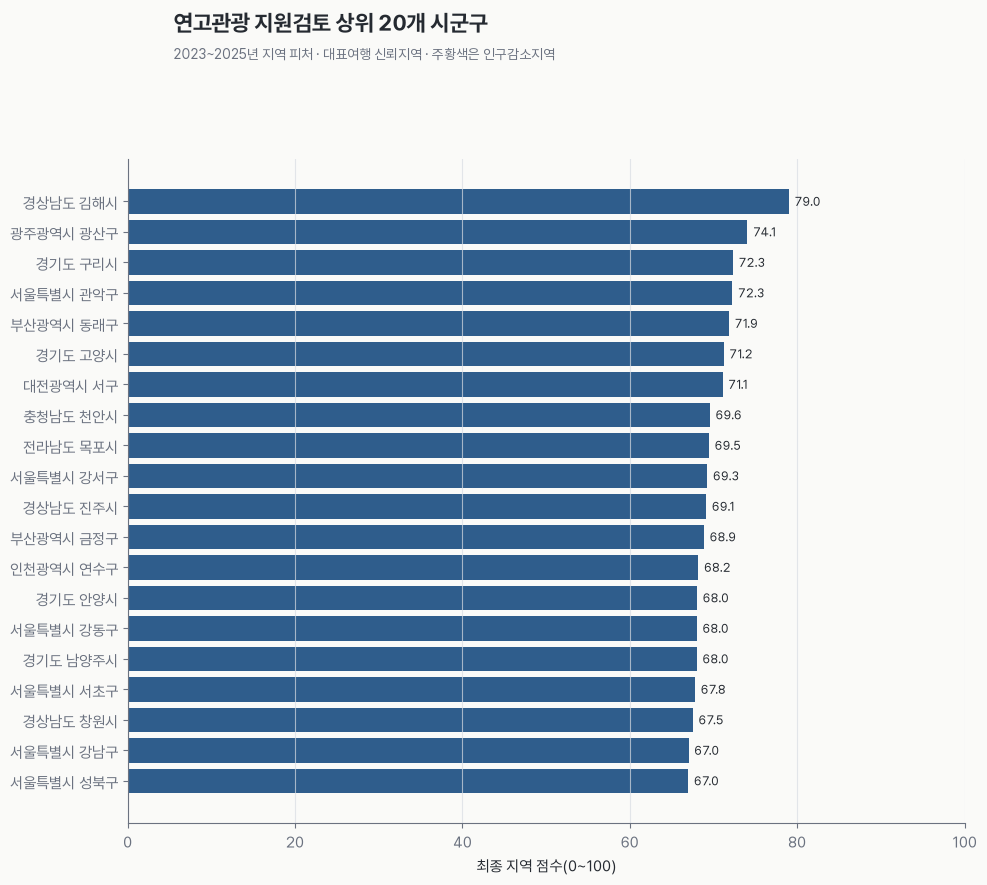

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_1035\figures\top20_final_scores.png


In [16]:
apply_plot_style()

top20 = (
    ordered_result.loc[
        ordered_result["지원검토_순위"].le(TOP_N)
    ]
    .sort_values("최종점수")
    .copy()
)
bar_colors = np.where(
    top20["인구감소지역"],
    COLORS["accent"],
    COLORS["primary"],
)

figure, axis = plt.subplots(figsize=(10, 9))
bars = axis.barh(
    top20["지역명"],
    top20["최종점수"],
    color=bar_colors,
)
axis.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
axis.set_xlim(0, 100)
axis.set_xlabel("최종 지역 점수(0~100)")
axis.set_ylabel("")
figure.suptitle(
    "연고관광 지원검토 상위 20개 시군구",
    x=0.18,
    y=0.98,
    ha="left",
)
figure.text(
    0.18,
    0.925,
    "2023~2025년 지역 피처 · 대표여행 신뢰지역 · "
    "주황색은 인구감소지역",
    color=COLORS["neutral"],
    fontsize=10,
)
axis.grid(axis="x")
figure.tight_layout(rect=(0, 0, 1, 0.88))

top20_figure_path = FIGURES_DIR / "top20_final_scores.png"
figure.savefig(top20_figure_path, dpi=900)
plt.show()
print(f"저장 그림: {top20_figure_path}")

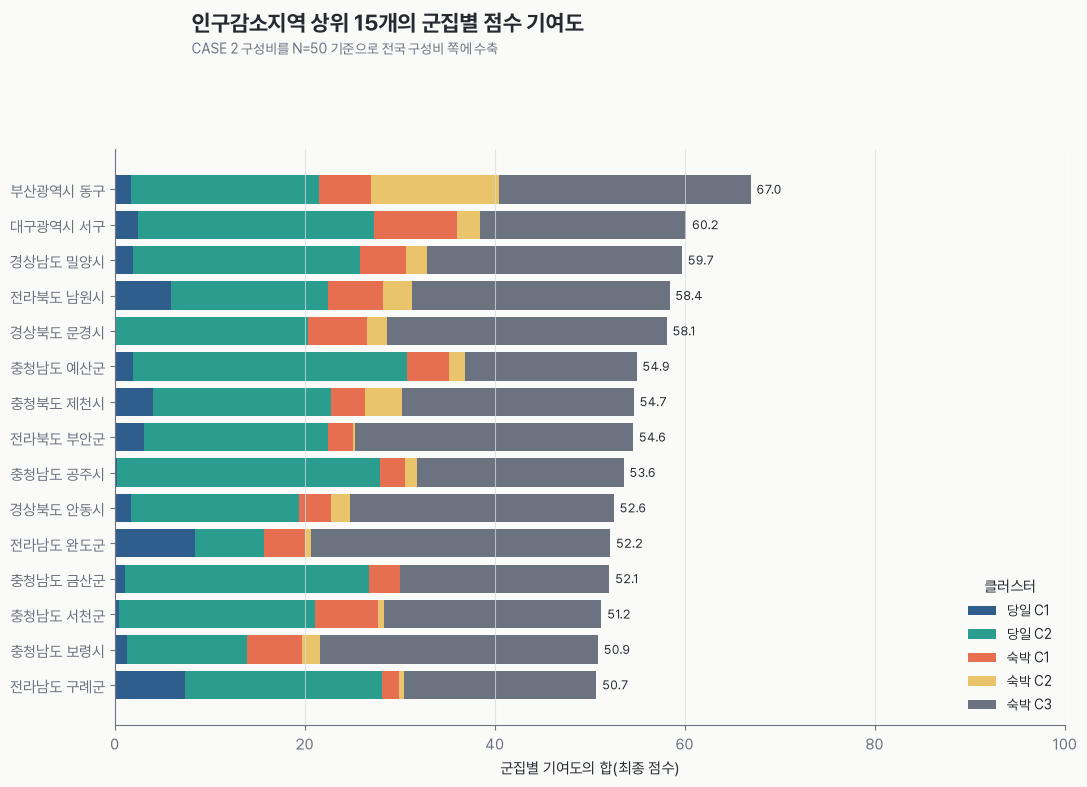

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_1035\figures\population_decline_top15_contributions.png


In [17]:
apply_plot_style()

population_top = (
    ordered_result.loc[
        ordered_result["인구감소지역"]
        & ordered_result["is_reliable_rep_trip_case124"]
    ]
    .nsmallest(15, "지원검토_순위")
    .sort_values("최종점수")
    .copy()
)
contribution_columns = [
    f"기여도_{label}" for label in CLUSTER_LABELS
]

figure, axis = plt.subplots(figsize=(11, 8))
left = np.zeros(len(population_top))
for label, color in zip(CLUSTER_LABELS, PALETTE, strict=True):
    values = population_top[f"기여도_{label}"].to_numpy()
    axis.barh(
        population_top["지역명"],
        values,
        left=left,
        label=label,
        color=color,
    )
    left += values

for position, score in enumerate(population_top["최종점수"]):
    axis.text(
        score + 0.6,
        position,
        f"{score:.1f}",
        va="center",
        fontsize=9,
    )
axis.set_xlim(0, 100)
axis.set_xlabel("군집별 기여도의 합(최종 점수)")
axis.set_ylabel("")
figure.suptitle(
    "인구감소지역 상위 15개의 군집별 점수 기여도",
    x=0.18,
    y=0.98,
    ha="left",
)
figure.text(
    0.18,
    0.925,
    "CASE 2 구성비를 N=50 기준으로 전국 구성비 쪽에 수축",
    color=COLORS["neutral"],
    fontsize=10,
)
axis.legend(
    title="클러스터",
    loc="lower right",
    frameon=False,
)
axis.grid(axis="x")
figure.tight_layout(rect=(0, 0, 1, 0.88))

contribution_figure_path = (
    FIGURES_DIR / "population_decline_top15_contributions.png"
)
figure.savefig(contribution_figure_path, dpi=900)
plt.show()
print(f"저장 그림: {contribution_figure_path}")

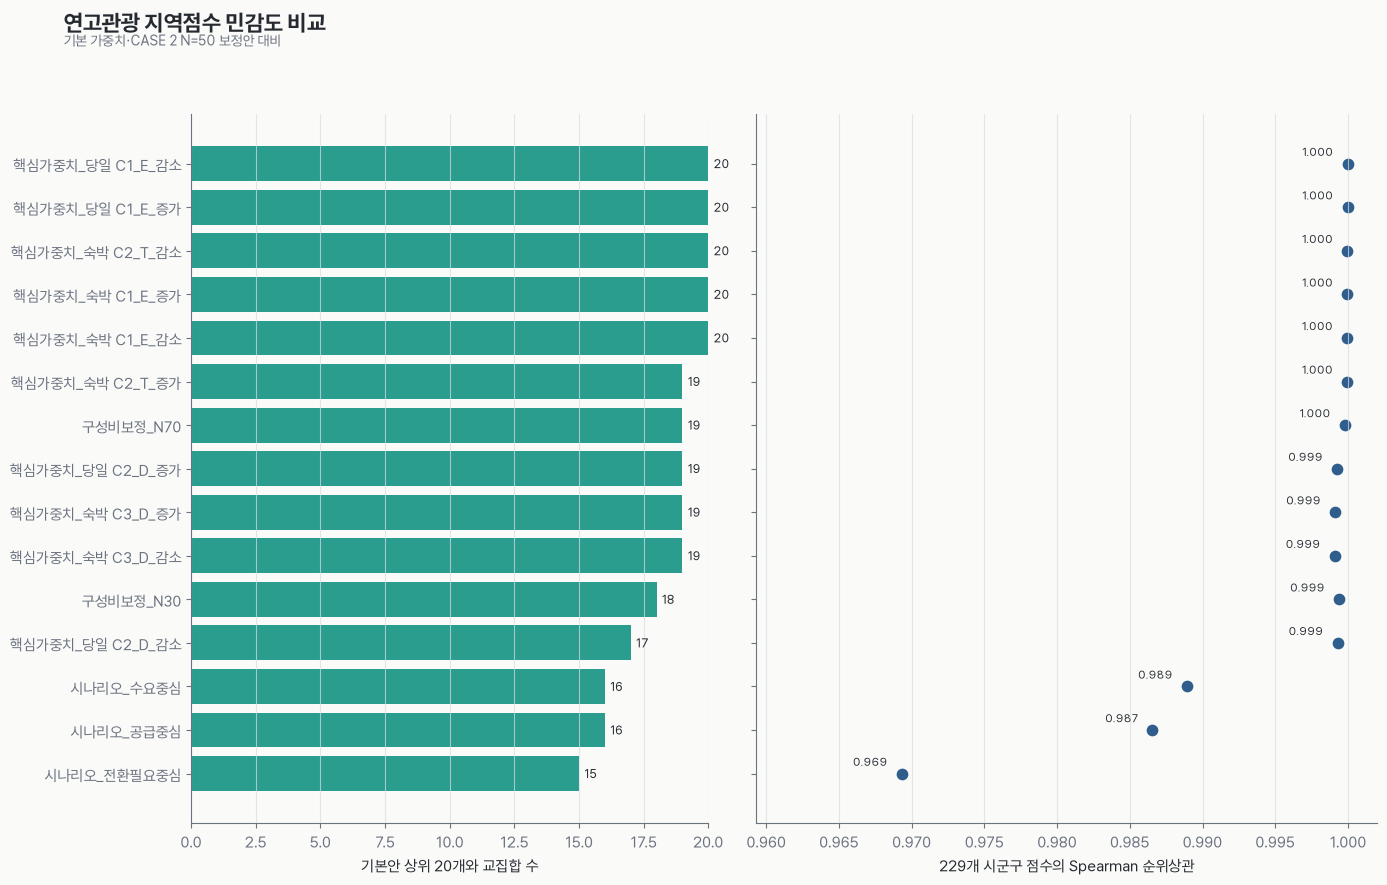

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_1035\figures\sensitivity_comparison.png


In [18]:
apply_plot_style()

sensitivity_plot = (
    sensitivity_summary.loc[
        sensitivity_summary["변형"].ne("기본안")
    ]
    .sort_values(
        ["기본안_상위20_교집합수", "Spearman_순위상관"]
    )
    .reset_index(drop=True)
)
y_positions = np.arange(len(sensitivity_plot))

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 9),
    sharey=True,
    gridspec_kw={"width_ratios": [1.0, 1.2]},
)
axes[0].barh(
    y_positions,
    sensitivity_plot["기본안_상위20_교집합수"],
    color=COLORS["secondary"],
)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(sensitivity_plot["변형"])
axes[0].set_xlim(0, TOP_N)
axes[0].set_xlabel("기본안 상위 20개와 교집합 수")
axes[0].grid(axis="x")
for position, value in enumerate(
    sensitivity_plot["기본안_상위20_교집합수"]
):
    axes[0].text(
        value + 0.2,
        position,
        f"{value}",
        va="center",
        fontsize=9,
    )

axes[1].scatter(
    sensitivity_plot["Spearman_순위상관"],
    y_positions,
    color=COLORS["primary"],
    s=55,
)
axes[1].set_xlim(
    max(
        0.0,
        sensitivity_plot["Spearman_순위상관"].min() - 0.01,
    ),
    1.002,
)
axes[1].set_xlabel("229개 시군구 점수의 Spearman 순위상관")
axes[1].grid(axis="x")
for position, value in enumerate(
    sensitivity_plot["Spearman_순위상관"]
):
    axes[1].text(
        value - 0.001,
        position + 0.18,
        f"{value:.3f}",
        ha="right",
        fontsize=8,
    )

figure.suptitle(
    "연고관광 지역점수 민감도 비교",
    x=0.05,
    ha="left",
)
figure.text(
    0.05,
    0.94,
    "기본 가중치·CASE 2 N=50 보정안 대비",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.93))

sensitivity_figure_path = FIGURES_DIR / "sensitivity_comparison.png"
figure.savefig(sensitivity_figure_path, dpi=900)
plt.show()
print(f"저장 그림: {sensitivity_figure_path}")

## 핵심 결과와 한계

아래 셀은 실행 결과에서 점수 범위, 1차 시범지역, 민감도 안정성을
자동 요약한다.

해석 시 다음 한계를 유지한다.

- 철도·버스 운행 빈도, 실제 소요시간과 환승 편의는 반영하지 못한다.
- 다인실·단체주차·대규모 식당 수용력은 숙박·식음·체험 공급의
  대리변수를 사용한다.
- CASE 2 N은 군집 라벨이 있는 대표여행의 정확한 분모가 아니다.
- 가중치는 정책 판단을 수치화한 값이며 데이터가 자동 추정한 인과계수가
  아니다.
- 상위지역 간 작은 점수 차이는 고정된 서열보다 동점권으로 해석한다.

In [19]:
pilot_regions = ordered_result.loc[
    ordered_result["정책후보_유형"].eq("1차 시범지역"),
    ["지원검토_순위", "지역명", "최종점수", "주력군집"],
]
nonbaseline_sensitivity = sensitivity_summary.loc[
    sensitivity_summary["변형"].ne("기본안")
]
score_gap = (
    ordered_result.loc[
        ordered_result["지원검토_순위"].le(TOP_N),
        "최종점수",
    ]
    .sort_values(ascending=False)
    .diff(-1)
    .abs()
)

summary_text = f"""
### 실행 요약

- 229개 시군구의 기본 최종 점수 범위는
  **{result['최종점수'].min():.2f}~{result['최종점수'].max():.2f}점**이다.
- 대표여행 신뢰 플래그가 거짓인
  **{(~result['is_reliable_rep_trip_case124']).sum()}개 지역**은
  지원검토 순위에서 분리했다.
- 인구감소지역 89개 중 지원검토 상위 {TOP_N}에 포함되고
  CASE 2 N≥30인 1차 시범지역은 **{len(pilot_regions)}개**다.
- 민감도 변형의 기본안 대비 Spearman 순위상관 최솟값은
  **{nonbaseline_sensitivity['Spearman_순위상관'].min():.3f}**,
  상위 20개 교집합의 최솟값은
  **{nonbaseline_sensitivity['기본안_상위20_교집합수'].min()}개**다.
- 기본안 상위 20개에서 인접 순위 간 점수 차이의 중앙값은
  **{score_gap.dropna().median():.2f}점**이므로 작은 차이를 과도한
  서열로 해석하지 않는다.
"""
display(Markdown(summary_text))
display(pilot_regions.style.format(
    {
        "지원검토_순위": "{:.0f}",
        "최종점수": "{:.2f}",
    }
))


### 실행 요약

- 229개 시군구의 기본 최종 점수 범위는
  **21.10~79.01점**이다.
- 대표여행 신뢰 플래그가 거짓인
  **2개 지역**은
  지원검토 순위에서 분리했다.
- 인구감소지역 89개 중 지원검토 상위 20에 포함되고
  CASE 2 N≥30인 1차 시범지역은 **0개**다.
- 민감도 변형의 기본안 대비 Spearman 순위상관 최솟값은
  **0.969**,
  상위 20개 교집합의 최솟값은
  **15개**다.
- 기본안 상위 20개에서 인접 순위 간 점수 차이의 중앙값은
  **0.21점**이므로 작은 차이를 과도한
  서열로 해석하지 않는다.


,지원검토_순위,지역명,최종점수,주력군집


In [ ]:
from src.notebook_sync import sync_script_from_notebook

sync_script_from_notebook(
    "notebooks/06_Score/previous/"
    "260726_연고관광_클러스터별_지역점수.ipynb",
    script_path=(
        "script/"
        "260726_연고관광_클러스터별_지역점수_previous.py"
    ),
)